Using device: cuda
OOD DETECTOR TRAINING

PREPARING DATASET
Loading brain MRI images...
  ✓ Loaded 11300 brain MRI images
Loading non-MRI images (CIFAR-100)...
  ✓ Loaded 60000 non-MRI images

Total samples: 71300
  Positive (MRI): 11300
  Negative (non-MRI): 60000

Train samples: 57040
Val samples: 14260

INITIALIZING MODEL


Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to C:\Users\anish/.cache\torch\hub\checkpoints\mobilenet_v3_small-047dcff4.pth
100%|██████████| 9.83M/9.83M [00:02<00:00, 4.38MB/s]
c:\Users\anish\anaconda3\envs\gridlock\lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Total parameters: 964,001
Trainable parameters: 964,001

TRAINING OOD DETECTOR



Epoch [1/15]
  Train Loss: 0.0254 | Train Acc: 99.65%
  Val Loss: 0.0002 | Val Acc: 100.00%
  ✓ Best model saved (acc: 100.00%)



Epoch [2/15]
  Train Loss: 0.0004 | Train Acc: 100.00%
  Val Loss: 0.0000 | Val Acc: 100.00%


...


Epoch [11/15]
  Train Loss: 0.0000 | Train Acc: 100.00%
  Val Loss: 0.0000 | Val Acc: 100.00%



Epoch [12/15]
  Train Loss: 0.0000 | Train Acc: 100.00%
  Val Loss: 0.0000 | Val Acc: 100.00%



Epoch [13/15]
  Train Loss: 0.0000 | Train Acc: 100.00%
  Val Loss: 0.0000 | Val Acc: 100.00%



Epoch [14/15]
  Train Loss: 0.0000 | Train Acc: 100.00%
  Val Loss: 0.0000 | Val Acc: 100.00%



Epoch [15/15]
  Train Loss: 0.0000 | Train Acc: 100.00%
  Val Loss: 0.0000 | Val Acc: 100.00%

TRAINING COMPLETE
Best validation accuracy: 100.00%
Model saved to: ../models/ood_detector.pth

✓ Training curves saved to: ../results/ood_detector_training.png


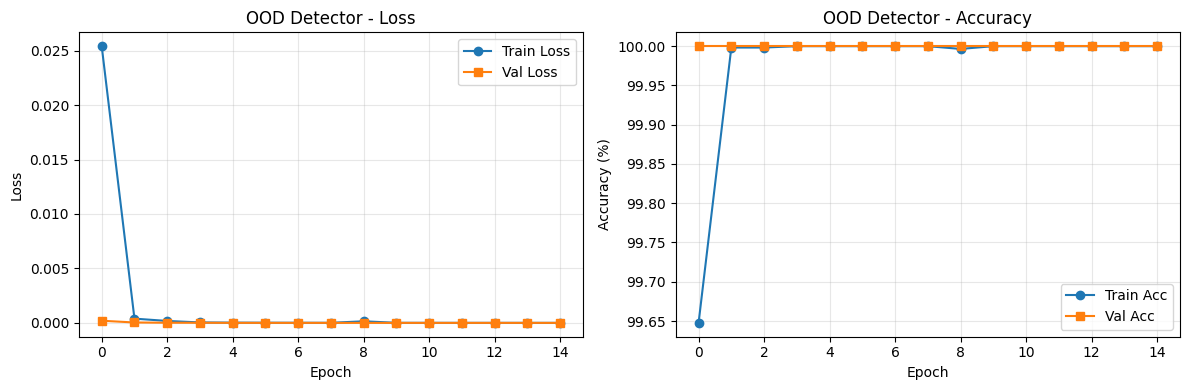


OOD Detector ready to use! ✓


In [1]:
import torch
import torch.nn as nn
from torchvision import models, transforms
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
from PIL import Image
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# ============================================================================
# 1. OOD DETECTOR MODEL
# ============================================================================

class OODDetector(nn.Module):
    """
    Binary classifier: Is this a brain MRI or not?
    Output: 1 = brain MRI, 0 = not brain MRI
    Uses MobileNetV3-Small (fast, lightweight)
    """
    def __init__(self):
        super().__init__()
        backbone = models.mobilenet_v3_small(
            weights=models.MobileNet_V3_Small_Weights.IMAGENET1K_V1
        )
        in_features = backbone.classifier[0].in_features
        
        # Replace classifier
        backbone.classifier = nn.Sequential(
            nn.Linear(in_features, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(64, 1)  # Single output for binary classification
        )
        self.backbone = backbone
    
    def forward(self, x):
        return self.backbone(x)


# ============================================================================
# 2. DATASET
# ============================================================================

class BinaryMRIDataset(Dataset):
    """
    Loads brain MRI images (label=1) and non-MRI images (label=0)
    """
    def __init__(self, mri_dir, non_mri_dir, transform=None, max_samples=None):
        self.transform = transform
        self.samples = []
        
        # Positive samples: Brain MRI (label = 1)
        print("Loading brain MRI images...")
        mri_path = Path(mri_dir)
        mri_count = 0
        for img_path in sorted(mri_path.rglob("*.jpg")) + sorted(mri_path.rglob("*.png")):
            if max_samples and mri_count >= max_samples:
                break
            self.samples.append((str(img_path), 1.0))
            mri_count += 1
        
        print(f"  ✓ Loaded {mri_count} brain MRI images")
        
        # Negative samples: Non-MRI images (label = 0)
        print("Loading non-MRI images (CIFAR-100)...")
        non_mri_path = Path(non_mri_dir)
        non_mri_count = 0
        
        # CIFAR-100 structure: train/images/ and test/images/
        for img_path in sorted(non_mri_path.rglob("*.png")) + sorted(non_mri_path.rglob("*.jpg")):
            if max_samples and non_mri_count >= max_samples:
                break
            self.samples.append((str(img_path), 0.0))
            non_mri_count += 1
        
        print(f"  ✓ Loaded {non_mri_count} non-MRI images")
        print(f"\nTotal samples: {len(self.samples)}")
        print(f"  Positive (MRI): {mri_count}")
        print(f"  Negative (non-MRI): {non_mri_count}")
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        try:
            image = Image.open(img_path).convert("RGB")
            if self.transform:
                image = self.transform(image)
            return image, torch.tensor(label, dtype=torch.float32)
        except Exception as e:
            print(f"Error loading {img_path}: {e}")
            # Return dummy data on error
            return torch.randn(3, 224, 224), torch.tensor(label, dtype=torch.float32)


# ============================================================================
# 3. TRAINING
# ============================================================================

def train_ood_detector(
    mri_dir="../data/raw",
    non_mri_dir="../data/non_mri",
    save_path="../models/ood_detector.pth",
    epochs=15,
    batch_size=64,
    learning_rate=1e-4
):
    """Train binary OOD detector."""
    
    # Transform
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(p=0.3),
        transforms.RandomRotation(degrees=10),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    ])
    
    val_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    ])
    
    # Dataset
    print("\n" + "="*60)
    print("PREPARING DATASET")
    print("="*60)
    dataset = BinaryMRIDataset(mri_dir, non_mri_dir, transform)
    
    # Train/Val split: 80/20
    n = len(dataset)
    n_train = int(0.8 * n)
    n_val = n - n_train
    
    train_ds, val_ds = torch.utils.data.random_split(
        dataset, [n_train, n_val],
        generator=torch.Generator().manual_seed(42)
    )
    
    train_loader = DataLoader(
        train_ds, 
        batch_size=batch_size, 
        shuffle=True, 
        num_workers=0,
        pin_memory=True
    )
    val_loader = DataLoader(
        val_ds, 
        batch_size=batch_size, 
        shuffle=False, 
        num_workers=0,
        pin_memory=True
    )
    
    print(f"\nTrain samples: {n_train}")
    print(f"Val samples: {n_val}")
    
    # Model
    print("\n" + "="*60)
    print("INITIALIZING MODEL")
    print("="*60)
    model = OODDetector().to(device)
    
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Total parameters: {total_params:,}")
    print(f"Trainable parameters: {trainable_params:,}")
    
    # Optimizer & loss
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    criterion = nn.BCEWithLogitsLoss()
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.5, patience=2, verbose=True
    )
    
    # Training loop
    print("\n" + "="*60)
    print("TRAINING OOD DETECTOR")
    print("="*60)
    
    history = {
        'train_loss': [],
        'val_loss': [],
        'train_acc': [],
        'val_acc': []
    }
    
    best_val_acc = 0.0
    
    for epoch in range(epochs):
        # TRAIN
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0
        
        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [TRAIN]", leave=False)
        for images, labels in pbar:
            images = images.to(device)
            labels = labels.to(device).unsqueeze(1)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            predicted = (torch.sigmoid(outputs) > 0.5).float().squeeze(1)
            train_correct += (predicted == labels.squeeze(1)).sum().item()
            train_total += labels.size(0)
            
            pbar.set_postfix({'loss': f'{loss.item():.4f}'})
        
        train_loss /= len(train_loader)
        train_acc = 100 * train_correct / train_total
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        
        # VALIDATE
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0
        
        with torch.no_grad():
            pbar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [VAL]", leave=False)
            for images, labels in pbar:
                images = images.to(device)
                labels = labels.to(device).unsqueeze(1)
                
                outputs = model(images)
                loss = criterion(outputs, labels)
                
                val_loss += loss.item()
                predicted = (torch.sigmoid(outputs) > 0.5).float().squeeze(1)
                val_correct += (predicted == labels.squeeze(1)).sum().item()
                val_total += labels.size(0)
                
                pbar.set_postfix({'loss': f'{loss.item():.4f}'})
        
        val_loss /= len(val_loader)
        val_acc = 100 * val_correct / val_total
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        
        print(f"\nEpoch [{epoch+1}/{epochs}]")
        print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
        print(f"  Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")
        
        # Save best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save({
                'model_state_dict': model.state_dict(),
                'epoch': epoch,
                'best_val_acc': best_val_acc,
                'history': history
            }, save_path)
            print(f"  ✓ Best model saved (acc: {val_acc:.2f}%)")
        
        scheduler.step(val_acc)
    
    print("\n" + "="*60)
    print("TRAINING COMPLETE")
    print("="*60)
    print(f"Best validation accuracy: {best_val_acc:.2f}%")
    print(f"Model saved to: {save_path}")
    
    return history, model


# ============================================================================
# 4. VISUALIZATION
# ============================================================================

def plot_training_history(history):
    """Plot training curves."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Loss
    axes[0].plot(history['train_loss'], label='Train Loss', marker='o')
    axes[0].plot(history['val_loss'], label='Val Loss', marker='s')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('OOD Detector - Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Accuracy
    axes[1].plot(history['train_acc'], label='Train Acc', marker='o')
    axes[1].plot(history['val_acc'], label='Val Acc', marker='s')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy (%)')
    axes[1].set_title('OOD Detector - Accuracy')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('../results/ood_detector_training.png', dpi=150, bbox_inches='tight')
    print("\n✓ Training curves saved to: ../results/ood_detector_training.png")
    plt.show()


# ============================================================================
# 5. RUN TRAINING
# ============================================================================

print("="*60)
print("OOD DETECTOR TRAINING")
print("="*60)

history, model = train_ood_detector(
    mri_dir="../data/raw",
    non_mri_dir="../data/non_mri",
    save_path="../models/ood_detector.pth",
    epochs=15,
    batch_size=64,
    learning_rate=1e-4
)

plot_training_history(history)

print("\nOOD Detector ready to use! ✓")